In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib.colors import ListedColormap, BoundaryNorm
import csv

%matplotlib widget


In [3]:
# import the needed data for each framework

def import_all_simulation_data(framework_head, optional_key=None):
    # framework = '1000_Data/' +  framework_head +'_MonolayerGrowth_1000_Data/'
    framework = '1000_Data_Slower/' +  framework_head +'_MonolayerGrowth_1000_Data' + optional_key + '/'

    # Aggregate data from all 100 simulations
    all_x_vals = []
    all_y_vals = []
    all_r_vals = []
    all_surface_fractions = []
    all_area_fractions = []
    all_inhibited_cells = []

    if framework_head == 'TST' or framework_head == 'Artistoo' or framework_head == 'Morpheus':
        iter_vals = range(1, 101)
    elif optional_key is not None and "SMALL" in optional_key:
        iter_vals = range(0, 10)
    else:
        iter_vals = range(0, 100)
    

    for index in iter_vals:
        if framework_head == 'Artistoo':
            file_path = os.path.join(framework, f'cell_data_no_inhibition_{index:03d}.csv')
        elif framework_head == 'CC3D':
            file_path = os.path.join(framework, f'cell_data_no_inhibition_{index:03d}.csv')
        else:
            file_path = os.path.join(framework, f'cell_data_no_inhibition_{index}.csv')
        
        if framework_head == 'Morpheus':
            data = np.loadtxt(file_path, delimiter='\t', skiprows=1)

            x_vals_tmp = data[:, 2]
            y_vals_tmp = data[:, 3]
            r_vals_tmp = data[:, 4]

            # r_vals = r_vals_tmp/(np.mean(r_vals_tmp))
            # x_vals = x_vals_tmp/(np.mean(r_vals_tmp))
            # y_vals = y_vals_tmp/(np.mean(r_vals_tmp))
            r_vals = r_vals_tmp
            x_vals = x_vals_tmp
            y_vals = y_vals_tmp

            surface_fractions = data[:, 5]
            area_fractions = data[:, 6]
            
            all_x_vals.extend(x_vals)
            all_y_vals.extend(y_vals)
            all_r_vals.extend(r_vals)
            all_surface_fractions.extend(surface_fractions)
            all_area_fractions.extend(area_fractions)

        elif framework_head == 'CC3D':
            data = np.loadtxt(file_path, delimiter=',', skiprows=1)
            
            x_vals_tmp = data[:, 0]
            y_vals_tmp = data[:, 1]
            r_vals_tmp = data[:, 2]
            surface_fractions = data[:, 3]
            area_fractions = data[:, 4]

            x_0 = np.mean(x_vals_tmp)
            y_0 = np.mean(y_vals_tmp)
            
            # r_vals = r_vals_tmp/(np.mean(r_vals_tmp))
            # x_vals = (x_vals_tmp - x_0)/(np.mean(r_vals_tmp))
            # y_vals = (y_vals_tmp - y_0)/(np.mean(r_vals_tmp))
            r_vals = r_vals_tmp
            x_vals = (x_vals_tmp - x_0)
            y_vals = (y_vals_tmp - y_0)
        
            all_x_vals.extend(x_vals)
            all_y_vals.extend(y_vals)
            all_r_vals.extend(r_vals)
            all_surface_fractions.extend(surface_fractions)
            all_area_fractions.extend(area_fractions)

        else:
            data = np.loadtxt(file_path, delimiter=',', skiprows=1)
            
            x_vals_tmp = data[:, 0]
            y_vals_tmp = data[:, 1]
            r_vals_tmp = data[:, 2]
            surface_fractions = data[:, 3]
            area_fractions = data[:, 4]

            # r_vals = r_vals_tmp/(np.mean(r_vals_tmp))
            # x_vals = x_vals_tmp/(np.mean(r_vals_tmp))
            # y_vals = y_vals_tmp/(np.mean(r_vals_tmp))
            r_vals = r_vals_tmp
            x_vals = x_vals_tmp
            y_vals = y_vals_tmp
        
            all_x_vals.extend(x_vals)
            all_y_vals.extend(y_vals)
            all_r_vals.extend(r_vals)
            all_surface_fractions.extend(surface_fractions)
            all_area_fractions.extend(area_fractions)

    if framework_head == 'TST':
        tmp_sf = all_surface_fractions
        tmp_af = all_area_fractions

        all_surface_fractions = tmp_af
        all_area_fractions = tmp_sf


    all_surface_fractions = np.array(all_surface_fractions)
    all_surface_fractions[all_surface_fractions < 0.0] = 0.0

    all_area_fractions = np.array(all_area_fractions)
    all_area_fractions[all_area_fractions < 0.0] = 0.0

    return all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions


In [131]:
# check if all_surface_fractions contains nans
# is_nan = (np.isnan(all_surface_fractions))
# all_surface_fractions[is_nan] = 0.0
is_nan = (np.isnan(all_y_vals)).any()
print(f"Does all_surface_fractions contain NaNs? {is_nan}")

Does all_surface_fractions contain NaNs? False


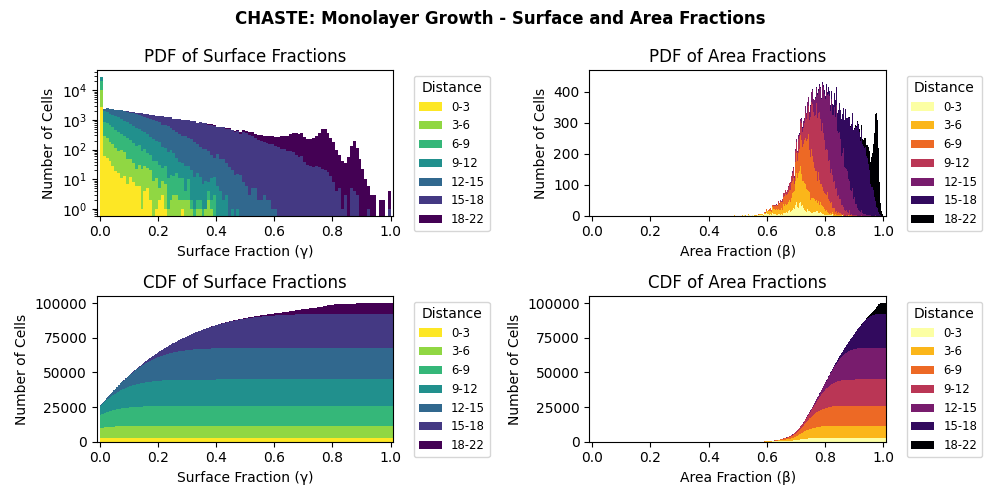

In [19]:

# framework_head = 'Artistoo'
framework_head = 'CHASTE'
# framework_head = 'PolyHoop'
# framework_head = 'TST'
# framework_head = 'Morpheus'
# framework_head = 'PhysiCell'
# framework_head = 'CC3D'

all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions = import_all_simulation_data(framework_head, '_QUADRATIC_LARGE_test9')
# all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions = import_all_simulation_data(framework_head, '')

# compute distances and distance bins

y_0 = np.mean(all_y_vals)
x_0 = np.mean(all_x_vals)

distances = np.sqrt((np.array(all_x_vals) - x_0)**2 + (np.array(all_y_vals) - y_0)**2)
max_distance = np.ceil(np.max(distances))

# distances = distances/max_distance  # normalize distances to [0, 1]

number_of_bins = 7

bins = np.linspace(0, 1.05*np.max(distances), number_of_bins + 1)

def make_stacked(fractions, distances, bins):
    stacked = [[] for _ in range(len(bins) - 1)]
    for dist, val in zip(distances, fractions):
        idx = np.searchsorted(bins, dist, side='right') - 1
        if 0 <= idx < len(stacked):
            stacked[idx].append(val)
    return stacked

stacked_sf = make_stacked(all_surface_fractions, distances, bins)
stacked_af = make_stacked(all_area_fractions, distances, bins)

labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]

# Plot stacked histograms
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

# Surface fraction stacked histogram
xlims1 = (-0.01, 1.01)
cmap = plt.cm.viridis_r
axs[0, 0].hist(stacked_sf, bins=np.arange(xlims1[0], xlims1[1], 0.01), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False)
axs[0, 0].set_title('PDF of Surface Fractions')
axs[0, 0].set_xlabel('Surface Fraction (γ)')
axs[0, 0].set_ylabel('Number of Cells')
axs[0, 0].set_yscale('log')
# axs[0].axvline(x=p_gamma, color='red', linestyle='--', label='γ Th.')
axs[0, 0].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
# set axis limits
axs[0, 0].set_xlim(xlims1)
# axs[0].set_ylim(1, None)


xlims2 = (-0.01, 1.01)
cmap = plt.cm.inferno_r
# Area fraction stacked histogram
axs[0, 1].hist(stacked_af, bins=np.arange(xlims2[0], xlims2[1], 0.001), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False)
axs[0, 1].set_title('PDF of Area Fractions')
axs[0, 1].set_xlabel('Area Fraction (β)')
axs[0, 1].set_ylabel('Number of Cells')
# axs[0, 1].set_yscale('log')
# axs[1].axvline(x=p_beta, color='red', linestyle='--', label='β Th.')
axs[0, 1].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axs[0, 1].set_xlim(xlims2)


# Surface fraction stacked histogram
# xlims1 = (0.7, 1.001)
cmap = plt.cm.viridis_r
axs[1, 0].hist(stacked_sf, bins=np.arange(xlims1[0], xlims1[1], 0.001), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False, cumulative=True)
axs[1, 0].set_title('CDF of Surface Fractions')
axs[1, 0].set_xlabel('Surface Fraction (γ)')
axs[1, 0].set_ylabel('Number of Cells')
# axs[0].set_yscale('log')
# axs[0].axvline(x=p_gamma, color='red', linestyle='--', label='γ Th.')
axs[1, 0].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
# set axis limits
axs[1, 0].set_xlim(xlims1)
# axs[0].set_ylim(1, None)


# xlims2 = (0.0, 1.01)
cmap = plt.cm.inferno_r
# Area fraction stacked histogram
axs[1, 1].hist(stacked_af, bins=np.arange(xlims2[0], xlims2[1], 0.001), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False, cumulative=True)
axs[1, 1].set_title('CDF of Area Fractions')
axs[1, 1].set_xlabel('Area Fraction (β)')
axs[1, 1].set_ylabel('Number of Cells')
# axs[1].set_yscale('log')
# axs[1].axvline(x=p_beta, color='red', linestyle='--', label='β Th.')
axs[1, 1].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axs[1, 1].set_xlim(xlims2)

plt.suptitle(framework_head + ': Monolayer Growth - Surface and Area Fractions', fontweight='bold')
plt.tight_layout()
plt.show()


# fname = f'{framework_head}_MonolayerGrowth_Surface_Area_Fractions'
# fig.savefig('1000_Data/' + fname + '.png', dpi=300, bbox_inches='tight')


In [125]:
len(all_surface_fractions[~np.isnan(all_surface_fractions)])

100264

In [ ]:
# from the CDF of Surface Fraction, calculate the 95%, 98%, 99% and 99.5% thresholds values for the surface fraction
framework_head = 'CHASTE'


gamma_thresholds = [0.95, 0.99, 0.999, 0.9995]
surface_fraction_thresholds = np.quantile(all_surface_fractions[~np.isnan(all_surface_fractions)], gamma_thresholds)

beta_thresholds = [0.95, 0.99, 0.999, 0.9995]
area_fraction_thresholds = np.quantile(all_area_fractions[~np.isnan(all_area_fractions)], beta_thresholds)

print(f'Surface fraction thresholds for {framework_head}:')
gamma_array = []
for t, th in zip(gamma_thresholds, surface_fraction_thresholds):
    print(f'{int(t*100)}%: {th:.6f}')
    gamma_array.append(th)

print(f'gamma_array = {[float(v) for v in gamma_array]}')
beta_array = []
print(f'Area fraction thresholds for {framework_head}:')
for t, th in zip(beta_thresholds, area_fraction_thresholds):
    print(f'{int(t*100)}%: {th:.6f}')
    beta_array.append(th)

print(f'beta_array = {[float(v) for v in beta_array]}')

Surface fraction thresholds for CHASTE:
95%: 0.677817
99%: 0.800954
99%: 0.890508
99%: 0.902354
gamma_array = [0.677817, 0.800954, 0.890508, 0.902354]
Area fraction thresholds for CHASTE:
95%: 0.971458
99%: 0.984134
99%: 0.991700
99%: 0.993896
beta_array = [0.971458, 0.984134, 0.9917, 0.993896]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


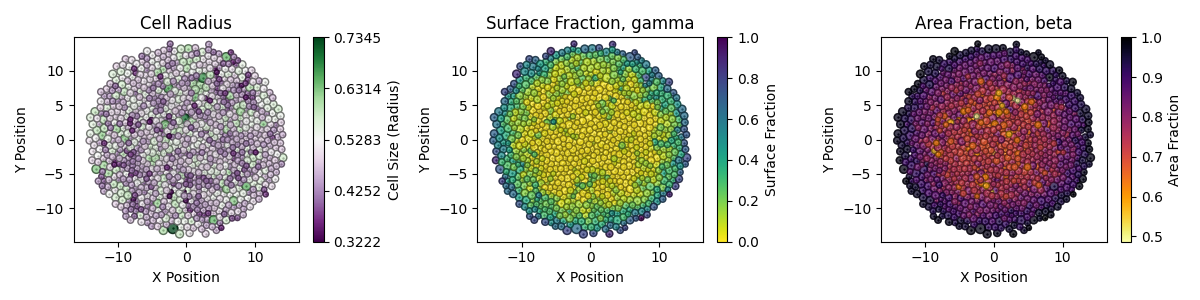

In [141]:
# framework_head = 'Artistoo'
# framework_head = 'CHASTE'
# framework_head = 'PolyHoop'
# framework_head = 'TST'
# framework_head = 'Morpheus'
# framework_head = 'PhysiCell'

framework_head = 'CHASTE'
subheaed = '_QUADRATIC_LARGE_Test'
framework = '1000_Data_Slower/' +  framework_head +'_MonolayerGrowth_1000_Data' + subheaed + '/'


# import the first simulation data for plotting
file_path = os.path.join(framework, f'cell_data_no_inhibition_3.csv')
data = np.loadtxt(file_path, delimiter=',', skiprows=1)
# data = np.loadtxt(file_path, delimiter='\t', skiprows=1)
x_vals_tmp = data[:, 0]
y_vals_tmp = data[:, 1]
r_vals_tmp = data[:, 2]

y_0 = np.mean(y_vals_tmp)
x_0 = np.mean(x_vals_tmp)

# r_vals = r_vals_tmp/(np.mean(r_vals_tmp))
# x_vals = (x_vals_tmp - x_0)/(np.mean(r_vals_tmp))
# y_vals = (y_vals_tmp - y_0)/(np.mean(r_vals_tmp))
r_vals = r_vals_tmp
x_vals = (x_vals_tmp - x_0)
y_vals = (y_vals_tmp - y_0)

surface_fractions = data[:, 3]
surface_fractions[surface_fractions < 0.0] = 0.0
area_fractions = data[:, 4]
area_fractions[area_fractions < 0.0] = 0.0

p_beta = 0.0
p_gamma = 0.0

lower_val = -np.max(np.abs([x_vals, y_vals]))
upper_val = np.max(np.abs([x_vals, y_vals]))
Window_Lim_x = (lower_val, upper_val)
Window_Lim_y = (lower_val, upper_val)


# precompute normalizations for the colorbars
norm_r = plt.Normalize(min(r_vals), max(r_vals))
norm_sf = plt.Normalize(min(surface_fractions), 1)
norm_af = plt.Normalize(min(area_fractions), 1)
norm_ih = plt.Normalize(0, 3)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

# Plot 1: Colour by radius
axs[0].scatter(x_vals, y_vals, s=0.5, color='black')
for x, y, r in zip(x_vals, y_vals, r_vals):
    color = plt.cm.PRGn(norm_r(r))
    circle_1 = plt.Circle((x, y), r, color=color, fill=True, alpha=0.75)
    circle_2 = plt.Circle((x, y), r, color='black', fill=False, alpha=0.5)
    axs[0].add_artist(circle_1)
    axs[0].add_artist(circle_2)
axs[0].set_title('Cell Radius')
axs[0].set_xlabel('X Position')
axs[0].set_ylabel('Y Position')
axs[0].axis('equal')
axs[0].set_xlim(Window_Lim_x)
axs[0].set_ylim(Window_Lim_y)
# axs[0].grid(True)
sm_r = plt.cm.ScalarMappable(norm=norm_r, cmap='PRGn')
sm_r.set_array([])
fig.colorbar(sm_r, ax=axs[0], label='Cell Size (Radius)', ticks=np.linspace(min(r_vals), max(r_vals), 5))


#------------------------------------------------------------------------------#
# Plot 2: Colour by surface fraction
axs[1].scatter(x_vals, y_vals, s=0.5, color='black')
for x, y, sf, r in zip(x_vals, y_vals, surface_fractions, r_vals):
    color = plt.cm.viridis_r(norm_sf(sf))
    circle_1 = plt.Circle((x, y), r, color=color, fill=True, alpha=0.75)
    circle_2 = plt.Circle((x, y), r, color='black', fill=False, alpha=0.5)
    axs[1].add_artist(circle_1)
    axs[1].add_artist(circle_2)
axs[1].set_title('Surface Fraction, gamma')
axs[1].set_xlabel('X Position')
axs[1].set_ylabel('Y Position')
axs[1].axis('equal')
axs[1].set_xlim(Window_Lim_x)
axs[1].set_ylim(Window_Lim_y)
# axs[1].grid(True)
sm_sf = plt.cm.ScalarMappable(norm=norm_sf, cmap='viridis_r')
sm_sf.set_array([])
fig.colorbar(sm_sf, ax=axs[1], label='Surface Fraction')

#------------------------------------------------------------------------------#
# Plot 3: Colour by area fraction
axs[2].scatter(x_vals, y_vals, s=0.5, color='black')
for x, y, af, r in zip(x_vals, y_vals, area_fractions, r_vals):
    color = plt.cm.inferno_r(norm_af(af))
    circle_1 = plt.Circle((x, y), r, color=color, fill=True, alpha=0.75)
    circle_2 = plt.Circle((x, y), r, color='black', fill=False, alpha=0.5)
    axs[2].add_artist(circle_1)
    axs[2].add_artist(circle_2)
axs[2].set_title('Area Fraction, beta')
axs[2].set_xlabel('X Position')
axs[2].set_ylabel('Y Position')
axs[2].axis('equal')
axs[2].set_xlim(Window_Lim_x)
axs[2].set_ylim(Window_Lim_y)
# axs[2].grid(True)
sm_af = plt.cm.ScalarMappable(norm=norm_af, cmap='inferno_r')
sm_af.set_array([])
fig.colorbar(sm_af, ax=axs[2], label='Area Fraction')

plt.tight_layout()
plt.show()


In [136]:
# framework_heads = ['Artistoo', 'TST', 'Morpheus','PolyHoop', 'CHASTE', 'PhysiCell']
framework_heads = ['Artistoo', 'CC3D', 'Morpheus', 'TST','PolyHoop', 'CHASTE', 'CHASTE', 'CHASTE',   'PhysiCell']
framework_options = [''      ,''      ,''      , '' ,        '','_LINEAR', '_LOG'  , '_QUADRATIC', '']


max_distance = 0
for iter, framework_head in enumerate(framework_heads):

    all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions = import_all_simulation_data(framework_head, framework_options[iter])
    y_0 = np.mean(all_y_vals)
    x_0 = np.mean(all_x_vals)

    distances = np.sqrt((np.array(all_x_vals) - x_0)**2 + (np.array(all_y_vals) - y_0)**2)
    distances = distances/all_r_vals
    max_distance = np.max([max_distance, np.ceil(np.max(distances))])

    print(f"{framework_head} - Max distance: {max_distance:.2f}")

max_distance

Artistoo - Max distance: 84.00
CC3D - Max distance: 103.00
Morpheus - Max distance: 103.00
TST - Max distance: 103.00
PolyHoop - Max distance: 103.00
CHASTE - Max distance: 103.00
CHASTE - Max distance: 103.00
CHASTE - Max distance: 103.00
PhysiCell - Max distance: 103.00


np.float64(103.0)

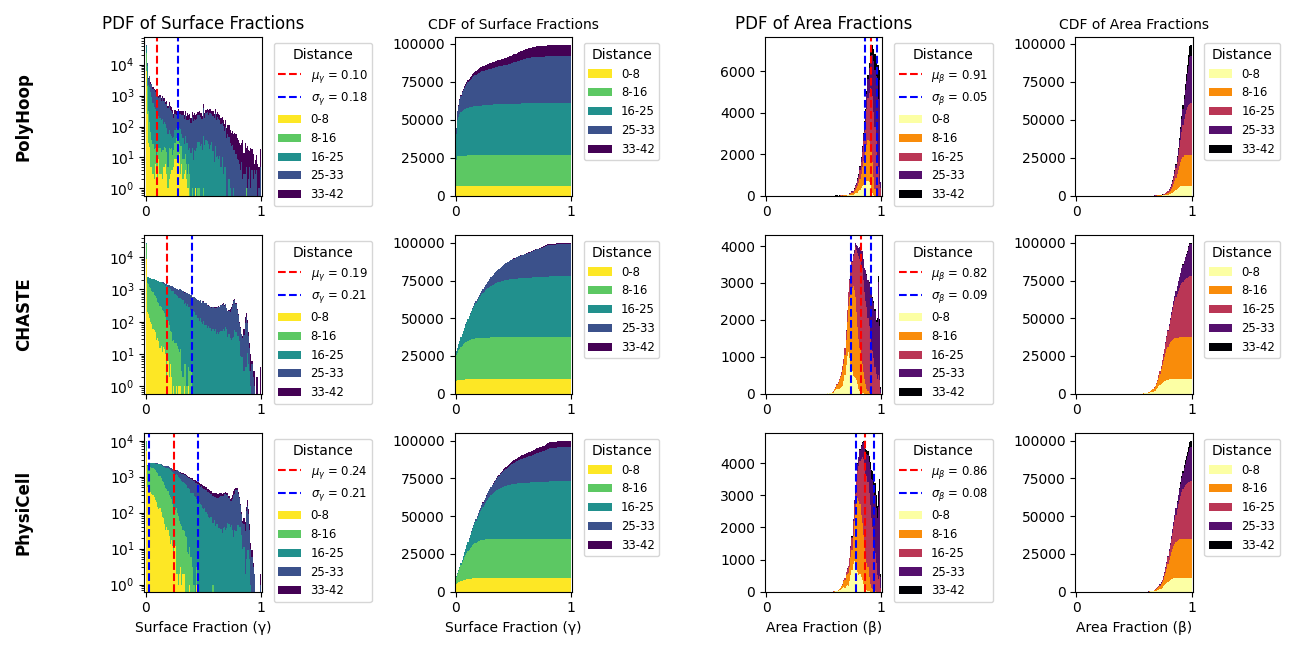

In [18]:

plot_mean_std = True

# framework_heads = ['Artistoo', 'TST', 'Morpheus','PolyHoop', 'CHASTE', 'PhysiCell']

# framework_heads = ['Artistoo', 'CC3D', 'Morpheus', 'TST','PolyHoop', 'CHASTE', 'CHASTE', 'CHASTE',   'PhysiCell']
# framework_options = [''      ,''      ,''      , '' ,        '','_LINEAR', '_LOG'  , '_QUADRATIC_New', '']

# framework_heads = ['PolyHoop', 'CHASTE', 'CHASTE', 'CHASTE', 'CHASTE', 'PhysiCell']
# framework_options = ['', '_QUADRATIC', '_QUADRATIC_SMALL_Def_Rad_OldCalc', '_QUADRATIC_SMALL_Def_Rad_NewCalc', '_QUADRATIC_SMALL_Def_Rad_DifCalc','']

framework_heads = ['PolyHoop','CHASTE', 'PhysiCell']
framework_options = [''  , '_QUADRATIC_LARGE_Test9', '']


# Plot stacked histograms
fig, axs = plt.subplots(len(framework_heads), 4, figsize=(13, 13*len(framework_heads)/6))

max_distance = 0
for iter, framework_head in enumerate(framework_heads):

    all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions = import_all_simulation_data(framework_head, framework_options[iter])
    y_0 = np.mean(all_y_vals)
    x_0 = np.mean(all_x_vals)

    distances = np.sqrt((np.array(all_x_vals) - x_0)**2 + (np.array(all_y_vals) - y_0)**2)
    distances = distances/all_r_vals
    # max_distance = np.max([max_distance, np.ceil(np.max(distances))])
    mean_distance = np.mean(distances)
    std_distance  = np.std(distances)
    two_std_distance = 2*std_distance + mean_distance
    max_distance = np.max([max_distance, np.ceil(two_std_distance)])


for iter, framework_head in enumerate(framework_heads):

    all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions = import_all_simulation_data(framework_head, framework_options[iter])

    y_0 = np.mean(all_y_vals)
    x_0 = np.mean(all_x_vals)

    distances = np.sqrt((np.array(all_x_vals) - x_0)**2 + (np.array(all_y_vals) - y_0)**2)
    distances = distances/all_r_vals

    # local_max_distance = np.max([max_distance, np.ceil(np.max(distances))])
    # distances = max_distance*distances/local_max_distance  # normalize distances to [0, 1]
    # local_max_distance = np.ceil(np.max(distances))
    # distances = max_distance*distances/local_max_distance  # normalize distances to [0, max_distance]

    # max_distance = np.ceil(np.max(distances))

    number_of_bins = 5

    bins = np.linspace(0, 1.05*max_distance, number_of_bins + 1)

    # the bins should be such that the area of the annuli are equal
    # bin_edges = np.linspace(0, np.sqrt(1.05*np.max(distances)), number_of_bins + 1)
    # bins = bin_edges**2

    def make_stacked(fractions, distances, bins):
        stacked = [[] for _ in range(len(bins) - 1)]
        for dist, val in zip(distances, fractions):
            idx = np.searchsorted(bins, dist, side='right') - 1
            if 0 <= idx < len(stacked):
                stacked[idx].append(val)
        return stacked

    stacked_sf = make_stacked(all_surface_fractions, distances, bins)
    stacked_af = make_stacked(all_area_fractions, distances, bins)

    labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]


    # Surface fraction stacked histogram
    xlims1 = (-0.01, 1.01)
    cmap = plt.cm.viridis_r
    if plot_mean_std:
        # compute the mean surface fraction for total distribution
        is_nan = (np.isnan(all_surface_fractions))
        all_surface_fractions[is_nan] = 0.0
        mean_surface_fraction = np.mean(all_surface_fractions)
        axs[iter, 0].axvline(x=mean_surface_fraction, color='red', linestyle='--', label=rf'$\mu_{{\gamma}}$ = {mean_surface_fraction:.2f}')
        standarddev_surface_fraction = np.std(all_surface_fractions)
        axs[iter, 0].axvline(x=mean_surface_fraction + standarddev_surface_fraction, color='blue', linestyle='--', label=rf'$\sigma_{{\gamma}}$ = {standarddev_surface_fraction:.2f}')
        axs[iter, 0].axvline(x=mean_surface_fraction - standarddev_surface_fraction, color='blue', linestyle='--')

     # Surface fraction stacked histogram

    axs[iter, 0].hist(stacked_sf, bins=np.arange(xlims1[0], xlims1[1], 0.01), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False)
    if iter == 0:
        axs[iter, 0].set_title('PDF of Surface Fractions')
    if iter == len(framework_heads)-1:
        axs[iter, 0].set_xlabel('Surface Fraction (γ)')
    axs[iter, 0].set_ylabel('Number of Cells')
    axs[iter, 0].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    axs[iter, 0].set_xlim(xlims1)
    axs[iter, 0].set_yscale('log')

    # Surface fraction stacked histogram
    # xlims1 = (0.7, 1.001)
    cmap = plt.cm.viridis_r
    axs[iter, 1].hist(stacked_sf, bins=np.arange(xlims1[0], xlims1[1], 0.01), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False, cumulative=True)
    if iter == len(framework_heads)-1:
        axs[iter, 1].set_xlabel('Surface Fraction (γ)')
    if iter == 0:
        axs[iter, 1].set_title('CDF of Surface Fractions', fontsize=10)
    axs[iter, 1].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    axs[iter, 1].set_xlim(xlims1)


    xlims2 = (-0.01, 1.01)
    cmap = plt.cm.inferno_r
    
    if plot_mean_std:
        # compute the mean area fraction for total distribution
        is_nan = (np.isnan(all_area_fractions))
        all_area_fractions[is_nan] = 0.0
        mean_area_fraction = np.mean(all_area_fractions)
        standardev_area_fraction = np.std(all_area_fractions)
        axs[iter, 2].axvline(x=mean_area_fraction, color='red', linestyle='--', label=rf'$\mu_{{\beta}}$ = {mean_area_fraction:.2f}')
        axs[iter, 2].axvline(x=mean_area_fraction + standardev_area_fraction, color='blue', linestyle='--', label=rf'$\sigma_{{\beta}}$ = {standardev_area_fraction:.2f}')
        axs[iter, 2].axvline(x=mean_area_fraction - standardev_area_fraction, color='blue', linestyle='--')

    # Area fraction stacked histogram
    axs[iter, 2].hist(stacked_af, bins=np.arange(xlims2[0], xlims2[1], 0.01), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False)
    if iter == 0:
        axs[iter, 2].set_title('PDF of Area Fractions')
    if iter == len(framework_heads)-1:
        axs[iter, 2].set_xlabel('Area Fraction (β)')
    axs[iter, 2].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    axs[iter, 2].set_xlim(xlims2)

    # xlims2 = (0.0, 1.01)
    cmap = plt.cm.inferno_r
    # Area fraction stacked histogram
    axs[iter, 3].hist(stacked_af, bins=np.arange(xlims2[0], xlims2[1], 0.01), stacked=True, label=labels, edgecolor='none', color=cmap(np.linspace(0, 1, len(labels))), density=False, cumulative=True)
    
    if iter == 0:
        axs[iter, 3].set_title('CDF of Area Fractions', fontsize=10)
    if iter == len(framework_heads)-1:
        axs[iter, 3].set_xlabel('Area Fraction (β)')
    axs[iter, 3].legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    axs[iter, 3].set_xlim(xlims2)

    # make a title for each row on the leftmost plot
    # axs[iter, 0].set_ylabel(framework_head , fontsize=12, fontweight='bold', rotation=90, labelpad=40)
    # axs[iter, 0].set_ylabel(framework_head + ' ' + framework_options[iter], fontsize=12, fontweight='bold', rotation=90, labelpad=40)
    # axs[iter, 0].set_ylabel(
    #     f"{framework_head}\n{framework_options[iter].replace('_QUADRATIC_SMALL', '')}",
    #     fontsize=12,
    #     fontweight='bold',
    #     rotation=90,
    #     labelpad=40
    # )
    axs[iter, 0].set_ylabel(
        f"{framework_head}\n",
        fontsize=12,
        fontweight='bold',
        rotation=90,
        labelpad=40
    )


plt.tight_layout()
plt.show()

# save the figure
fname = f'MonolayerGrowth_Surface_Area_Fractions_Comparison'
fig.savefig('1000_Data_Slower/' + fname + '.png', dpi=800, bbox_inches='tight')
# fig.savefig('1000_Data/' + fname + '.png', dpi=800, bbox_inches='tight')


CHASTE - Max distance: 47.00
PhysiCell - Max distance: 47.00


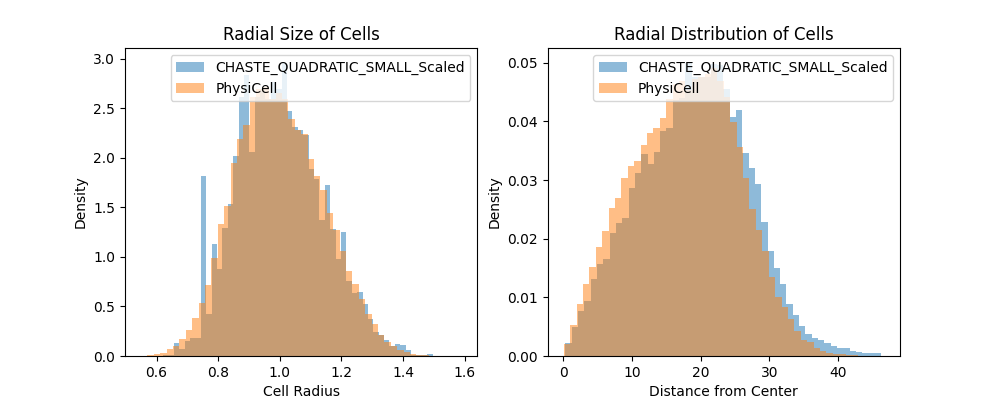

In [88]:
framework_heads = ['Artistoo', 'CC3D', 'Morpheus', 'TST','PolyHoop', 'CHASTE', 'CHASTE', 'CHASTE',   'PhysiCell']
framework_options = [''      ,''      ,''      , '' ,        '','_LINEAR', '_LOG'  , '_QUADRATIC', '']


framework_options = ['_QUADRATIC', '_QUADRATIC_SMALL_Scaled', '_QUADRATIC_SMALL_0p5', '']


framework_heads = ['CHASTE', 'PhysiCell']
framework_options = ['_QUADRATIC_SMALL_Scaled', '']


# Plot stacked histograms
fig, axs = plt.subplots(1, 2, figsize=(10, 4))


for iter, framework_head in enumerate(framework_heads):
    
    all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions = import_all_simulation_data(framework_head, framework_options[iter])
    
    # plot the radial disributions for each framework
    y_0 = np.mean(all_y_vals)
    x_0 = np.mean(all_x_vals)

    distances = np.sqrt((np.array(all_x_vals) - x_0)**2 + (np.array(all_y_vals) - y_0)**2)
    distances = distances/all_r_vals
    print(f"{framework_head} - Max distance: {np.ceil(np.max(distances)):.2f}")
    # local_max_distance = np.ceil(np.max(distances))
    # distances = max_distance*distances/local_max_distance  # normalize distances to [0, 1]
    
    all_r_vals = all_r_vals/np.mean(all_r_vals)

    
    axs[0].hist(all_r_vals, bins=50, density=True, alpha=0.5, label=framework_head + framework_options[iter])
    axs[0].set_xlabel('Cell Radius')
    axs[0].set_ylabel('Density')
    axs[0].set_title('Radial Size of Cells')
    axs[0].legend()

    axs[1].hist(distances, bins=50, density=True, alpha=0.5, label=framework_head + framework_options[iter])
    axs[1].set_xlabel('Distance from Center')
    axs[1].set_ylabel('Density')
    axs[1].set_title('Radial Distribution of Cells')
    axs[1].legend()
plt.show()



/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_39920/3426974724.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 1, figsize=(7, 5))


PhysiCell - Max distance: 47.00


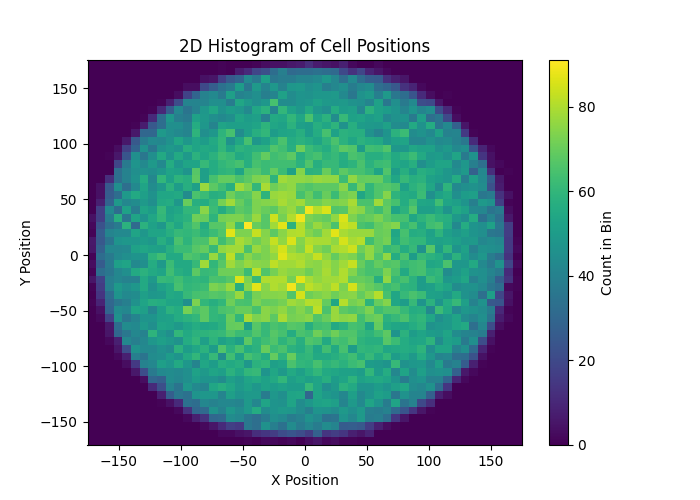

In [25]:
from scipy.stats import gaussian_kde

framework_heads = ['Artistoo', 'CC3D', 'Morpheus', 'TST','PolyHoop', 'CHASTE', 'CHASTE', 'CHASTE',   'PhysiCell']
framework_options = [''      ,''      ,''      , '' ,        '','_LINEAR', '_LOG'  , '_QUADRATIC', '']


framework_heads = ['PhysiCell']
framework_options = ['']


# Plot stacked histograms
fig, axs = plt.subplots(1, 1, figsize=(7, 5))


for iter, framework_head in enumerate(framework_heads):
    
    all_x_vals, all_y_vals, all_r_vals, all_surface_fractions, all_area_fractions = import_all_simulation_data(framework_head, framework_options[iter])
    
    # plot the radial disributions for each framework
    y_0 = np.mean(all_y_vals)
    x_0 = np.mean(all_x_vals)

    distances = np.sqrt((np.array(all_x_vals) - x_0)**2 + (np.array(all_y_vals) - y_0)**2)
    distances = distances/all_r_vals
    print(f"{framework_head} - Max distance: {np.ceil(np.max(distances)):.2f}")
    # local_max_distance = np.ceil(np.max(distances))
    # distances = max_distance*distances/local_max_distance  # normalize distances to [0, 1]
    
    
    # plt.scatter(all_x_vals, all_y_vals, s=0.5, color='black', alpha=0.5)
    # mplot the 2D histogram of the x and y values
    plt.hist2d(all_x_vals, all_y_vals, bins=50, cmap='viridis')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('2D Histogram of Cell Positions')
    plt.colorbar(label='Count in Bin')
plt.show()